# EDA — Telco Customer Churn

Exploratory analysis of the raw dataset: missing values, target distribution, and relationships between key variables and churn.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import seaborn as sns

from src.config import FIGURES_DIR
from src.data.load_data import load_raw_data

sns.set_theme(style="whitegrid")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = load_raw_data()
df.shape

2026-07-09 23:21:17,503 [INFO] Loaded raw data: 7043 rows, 21 columns


2026-07-09 23:21:17,506 [INFO] Filling 11 missing TotalCharges values with 0


2026-07-09 23:21:17,509 [INFO] Cleaned data: 7043 rows, 20 columns


(7043, 20)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304,0.265370
std,0.368612,24.559481,30.090047,2266.794470,0.441561
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.500000,398.550000,0.000000
50%,0.000000,29.000000,70.350000,1394.550000,0.000000
75%,0.000000,55.000000,89.850000,3786.600000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [4]:
# Missing values check (load_raw_data already handles the blank TotalCharges case)
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Target distribution

Churn is expected to be moderately imbalanced (roughly 27% churn in the full Telco dataset).

2026-07-09 23:21:17,583 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-09 23:21:17,591 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\Irfan\AppData\Local\Temp\ipykernel_9300\1215841181.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No Churn", "Churn"])


Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


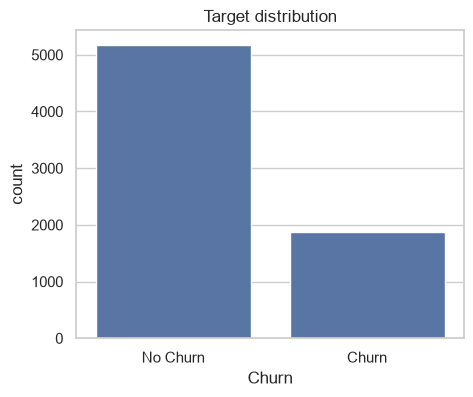

In [5]:
churn_counts = df["Churn"].value_counts(normalize=True)
print(churn_counts)

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="Churn", data=df, ax=ax)
ax.set_xticklabels(["No Churn", "Churn"])
ax.set_title("Target distribution")
fig.savefig(FIGURES_DIR / "churn_distribution.png", bbox_inches="tight")
plt.show()

## Tenure vs churn

Customers who churn tend to have lower tenure.

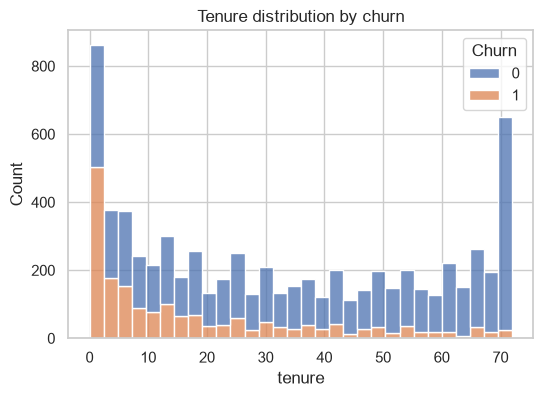

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(data=df, x="tenure", hue="Churn", multiple="stack", bins=30, ax=ax)
ax.set_title("Tenure distribution by churn")
fig.savefig(FIGURES_DIR / "tenure_by_churn.png", bbox_inches="tight")
plt.show()

## Contract type vs churn

Month-to-month contracts are expected to have a much higher churn rate than one/two-year contracts.

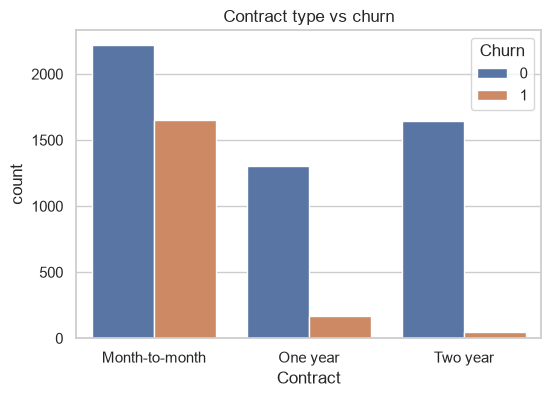

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x="Contract", hue="Churn", data=df, ax=ax)
ax.set_title("Contract type vs churn")
fig.savefig(FIGURES_DIR / "contract_vs_churn.png", bbox_inches="tight")
plt.show()

## Monthly charges vs churn

2026-07-09 23:21:18,386 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-07-09 23:21:18,394 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


C:\Users\Irfan\AppData\Local\Temp\ipykernel_9300\3240105766.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No Churn", "Churn"])


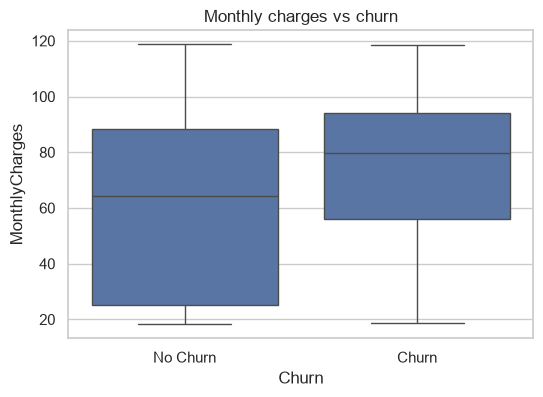

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, ax=ax)
ax.set_xticklabels(["No Churn", "Churn"])
ax.set_title("Monthly charges vs churn")
fig.savefig(FIGURES_DIR / "monthly_charges_by_churn.png", bbox_inches="tight")
plt.show()

## Summary

- Target is moderately imbalanced (~27% churn). It's worth keeping in mind for model evaluation (prefer F1/ROC-AUC over accuracy alone).
- Lower tenure, month-to-month contracts, and higher monthly charges are all associated with higher churn, which is consistent with domain expectations.